# EDA 

### Setup and Loading

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Configure layout for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load data with the correct delimiter
# 'ignore_errors=True' can be useful during initial exploration if lines are malformed,
# but for a strict assessment, we start clean.
df = pl.read_csv("dataset.csv", separator=";")

# ID GENERATION 
# In production, this would come from the upstream Data warehouse.
# Since this is a raw dump, I'm synthesizing a stable ID. 

df = df.with_row_index(name="customer_id", offset=0)

# Move customer_id to the front for readability
df = df.select(["customer_id"] + [c for c in df.columns if c != "customer_id"])

# Quick sanitary check
print(f"Shape: {df.shape}")
print(df.schema)
df.head()

Shape: (45211, 18)
Schema([('customer_id', UInt32), ('age', Int64), ('job', String), ('marital', String), ('education', String), ('default', String), ('balance', Int64), ('housing', String), ('loan', String), ('contact', String), ('day', Int64), ('month', String), ('duration', Int64), ('campaign', Int64), ('pdays', Int64), ('previous', Int64), ('poutcome', String), ('y', String)])


customer_id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
u32,i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str,str
0,58,"""management""","""married""","""tertiary""","""no""",2143,"""yes""","""no""","""unknown""",5,"""may""",261,1,-1,0,"""unknown""","""no"""
1,44,"""technician""","""single""","""secondary""","""no""",29,"""yes""","""no""","""unknown""",5,"""may""",151,1,-1,0,"""unknown""","""no"""
2,33,"""entrepreneur""","""married""","""secondary""","""no""",2,"""yes""","""yes""","""unknown""",5,"""may""",76,1,-1,0,"""unknown""","""no"""
3,47,"""blue-collar""","""married""","""unknown""","""no""",1506,"""yes""","""no""","""unknown""",5,"""may""",92,1,-1,0,"""unknown""","""no"""
4,33,"""unknown""","""single""","""unknown""","""no""",1,"""no""","""no""","""unknown""",5,"""may""",198,1,-1,0,"""unknown""","""no"""


### Data quality and cleaning

In [2]:
print("--- CHECK DUPLICATES ---")

# 1. Exact Duplicates (excluding the generated customer_id)
# We check if the same data row appears multiple times.
cols_to_check = [c for c in df.columns if c != "customer_id"]
n_exact_dupes = df.select(cols_to_check).is_duplicated().sum()

if n_exact_dupes > 0:
    print(f"CRITICAL WARNING: Found {n_exact_dupes} exact duplicate rows.")
    # In a production pipeline, we would drop these to prevent leakage
    # df = df.unique(subset=cols_to_check, keep='first')
else:
    print("Pass: No exact duplicates found.")

# 2. Near-Duplicates (Entity Resolution Heuristic)
# Hypothesis: If Age, Job, Marital Status, and Balance are identical, 
# it's likely the same person contacted multiple times.
# We should be careful not to put the same person in Train AND Validation.
proxy_id_cols = ["age", "job", "marital", "education", "balance", "housing", "loan"]
n_near_dupes = df.select(proxy_id_cols).is_duplicated().sum()

print(f"Insight: Found {n_near_dupes} rows that share identical demographic/financial profiles.")
print(f"({n_near_dupes / df.height:.2%} of data potential repeat customers)")

# Visualize an example of a potential repeat customer
if n_near_dupes > 0:
    # Find a profile that appears more than once
    repeat_profile = df.group_by(proxy_id_cols).len().filter(pl.col("len") > 1).head(1)
    
    # Join back to see the full rows
    if not repeat_profile.is_empty():
        print("\nExample of potential repeat customer entries:")
        example_dupes = df.join(repeat_profile, on=proxy_id_cols, how="inner").sort(proxy_id_cols)
        print(example_dupes.select(["customer_id", "day", "month", "campaign", "y", "balance"]))

--- CHECK DUPLICATES ---
Pass: No exact duplicates found.
Insight: Found 7322 rows that share identical demographic/financial profiles.
(16.20% of data potential repeat customers)

Example of potential repeat customer entries:
shape: (2, 6)
┌─────────────┬─────┬───────┬──────────┬─────┬─────────┐
│ customer_id ┆ day ┆ month ┆ campaign ┆ y   ┆ balance │
│ ---         ┆ --- ┆ ---   ┆ ---      ┆ --- ┆ ---     │
│ u32         ┆ i64 ┆ str   ┆ i64      ┆ str ┆ i64     │
╞═════════════╪═════╪═══════╪══════════╪═════╪═════════╡
│ 15379       ┆ 18  ┆ jul   ┆ 3        ┆ no  ┆ 1164    │
│ 25414       ┆ 18  ┆ nov   ┆ 2        ┆ no  ┆ 1164    │
└─────────────┴─────┴───────┴──────────┴─────┴─────────┘


In [3]:
# FINDING: 16% of the data rows are potential repeat customers
# I treat each unique combination of demographic features as one entity. 
# I use this profile_id later for a grouped split so each person appears only in train or test, which prevents leakage.

# Define columns that represent the "person" (immutable between calls)
static_cols = ["age", "job", "marital", "education", "balance", "housing", "loan"]

# Create a hash of these columns to act as a unique person identifier
df = df.with_columns(
    pl.concat_str(static_cols).hash().alias("profile_id")
)

# Verify the logic: Check how many unique "people" we have vs unique rows
n_people = df["profile_id"].n_unique()
print(f"Total Rows: {df.height}")
print(f"Unique 'People' (Entities): {n_people}")
print(f"Rows with history: {df.height - n_people}")

Total Rows: 45211
Unique 'People' (Entities): 40997
Rows with history: 4214


In [4]:
# 1. Check for standard Nulls
print("Standard Nulls:\n", df.null_count())

# 2. Check for "unknown" strings in categorical columns
# We filter for string columns first
str_cols = df.select(pl.col(pl.Utf8)).columns
unknown_counts = df.select([
    pl.col(c).str.contains("unknown").sum().alias(f"{c}_unknowns")
    for c in str_cols
])

print("\n'Unknown' value counts:")
print(unknown_counts.transpose(include_header=True))

# 3. Convert Target 'y' to binary integers (0/1) for easier analysis
# This creates a new column 'target' without modifying original 'y' yet
df = df.with_columns(
    pl.when(pl.col("y") == "yes").then(1).otherwise(0).alias("target")
)

Standard Nulls:
 shape: (1, 19)
┌─────────────┬─────┬─────┬─────────┬───┬──────────┬──────────┬─────┬────────────┐
│ customer_id ┆ age ┆ job ┆ marital ┆ … ┆ previous ┆ poutcome ┆ y   ┆ profile_id │
│ ---         ┆ --- ┆ --- ┆ ---     ┆   ┆ ---      ┆ ---      ┆ --- ┆ ---        │
│ u32         ┆ u32 ┆ u32 ┆ u32     ┆   ┆ u32      ┆ u32      ┆ u32 ┆ u32        │
╞═════════════╪═════╪═════╪═════════╪═══╪══════════╪══════════╪═════╪════════════╡
│ 0           ┆ 0   ┆ 0   ┆ 0       ┆ … ┆ 0        ┆ 0        ┆ 0   ┆ 0          │
└─────────────┴─────┴─────┴─────────┴───┴──────────┴──────────┴─────┴────────────┘

'Unknown' value counts:
shape: (10, 2)
┌────────────────────┬──────────┐
│ column             ┆ column_0 │
│ ---                ┆ ---      │
│ str                ┆ u32      │
╞════════════════════╪══════════╡
│ job_unknowns       ┆ 288      │
│ marital_unknowns   ┆ 0        │
│ education_unknowns ┆ 1857     │
│ default_unknowns   ┆ 0        │
│ housing_unknowns   ┆ 0        │
│ loan_

### Check for imbalance

shape: (2, 3)
┌─────┬───────┬────────────┐
│ y   ┆ count ┆ percentage │
│ --- ┆ ---   ┆ ---        │
│ str ┆ u32   ┆ f64        │
╞═════╪═══════╪════════════╡
│ no  ┆ 39922 ┆ 88.30152   │
│ yes ┆ 5289  ┆ 11.69848   │
└─────┴───────┴────────────┘


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/179270867.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_dist.to_pandas(), x="y", y="count", palette="viridis")


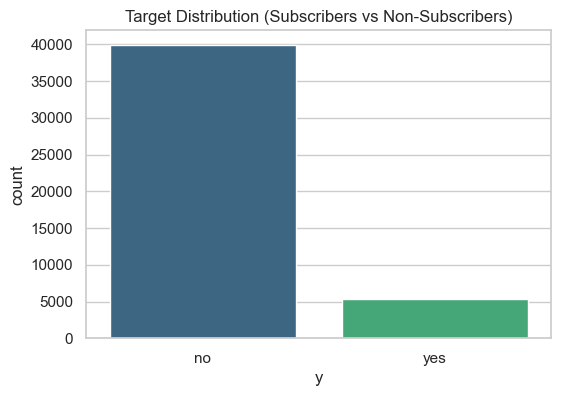

In [5]:
# Calculate counts and percentages
target_dist = df["y"].value_counts(sort=True).with_columns(
    (pl.col("count") / df.height * 100).alias("percentage")
)

print(target_dist)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=target_dist.to_pandas(), x="y", y="count", palette="viridis")
plt.title("Target Distribution (Subscribers vs Non-Subscribers)")
plt.show()

### Metric Baseline

In [6]:

# Calculate Baseline Accuracy (Zero Rule Algorithm)
# If we simply predicted "no" for every customer, how accurate would we be?
target_counts = df["y"].value_counts()
majority_class_count = target_counts.filter(pl.col("y") == "no")["count"][0]
total_count = df.height
baseline_acc = majority_class_count / total_count

print(f"Baseline Accuracy (predicting majority class 'no'): {baseline_acc:.4%}")
print("GOAL: Model must exceed this accuracy OR provide significant lift in F1-Score for the 'yes' class.")

Baseline Accuracy (predicting majority class 'no'): 88.3015%
GOAL: Model must exceed this accuracy OR provide significant lift in F1-Score for the 'yes' class.


### Distribution and outliers

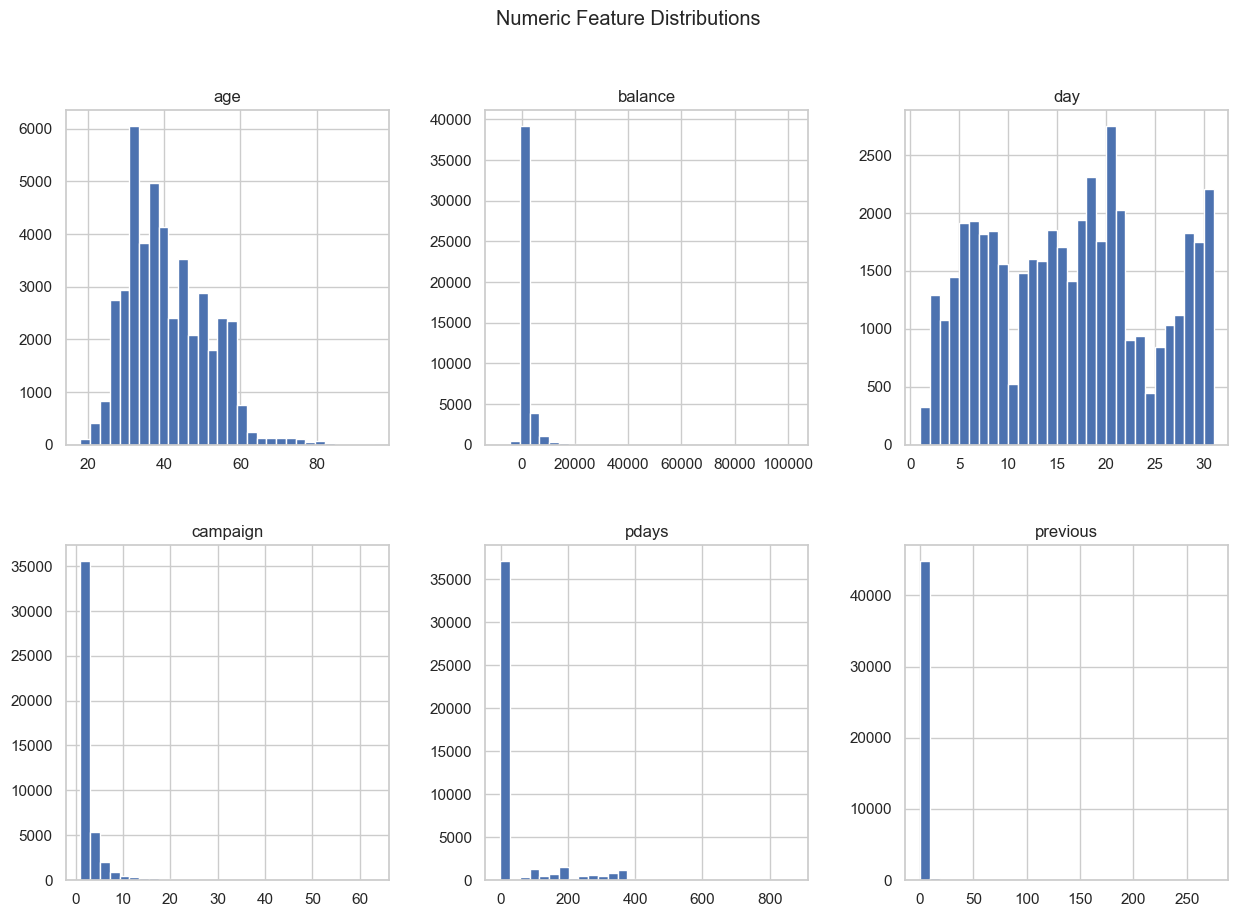

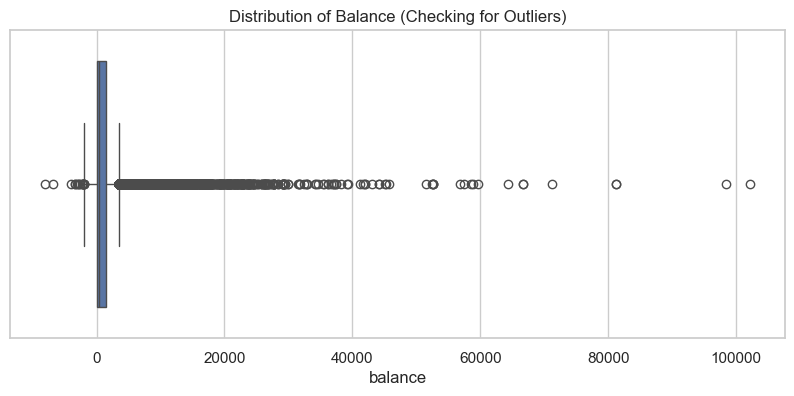

In [7]:
num_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

# Plot histograms to see skewness
df.select(num_cols).to_pandas().hist(bins=30, figsize=(15, 10), layout=(2, 3))
plt.suptitle("Numeric Feature Distributions")
plt.show()

# Boxplot for Balance (checking for wealthy outliers)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["balance"].to_pandas())
plt.title("Distribution of Balance (Checking for Outliers)")
plt.show()

### Categorical Features vs. Target

shape: (12, 3)
┌──────────────┬───────┬─────────────────┐
│ job          ┆ count ┆ conversion_rate │
│ ---          ┆ ---   ┆ ---             │
│ str          ┆ u32   ┆ f64             │
╞══════════════╪═══════╪═════════════════╡
│ student      ┆ 938   ┆ 0.28678         │
│ retired      ┆ 2264  ┆ 0.227915        │
│ unemployed   ┆ 1303  ┆ 0.155027        │
│ management   ┆ 9458  ┆ 0.137556        │
│ admin.       ┆ 5171  ┆ 0.122027        │
│ …            ┆ …     ┆ …               │
│ technician   ┆ 7597  ┆ 0.11057         │
│ services     ┆ 4154  ┆ 0.08883         │
│ housemaid    ┆ 1240  ┆ 0.087903        │
│ entrepreneur ┆ 1487  ┆ 0.082717        │
│ blue-collar  ┆ 9732  ┆ 0.07275         │
└──────────────┴───────┴─────────────────┘


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/3560971658.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


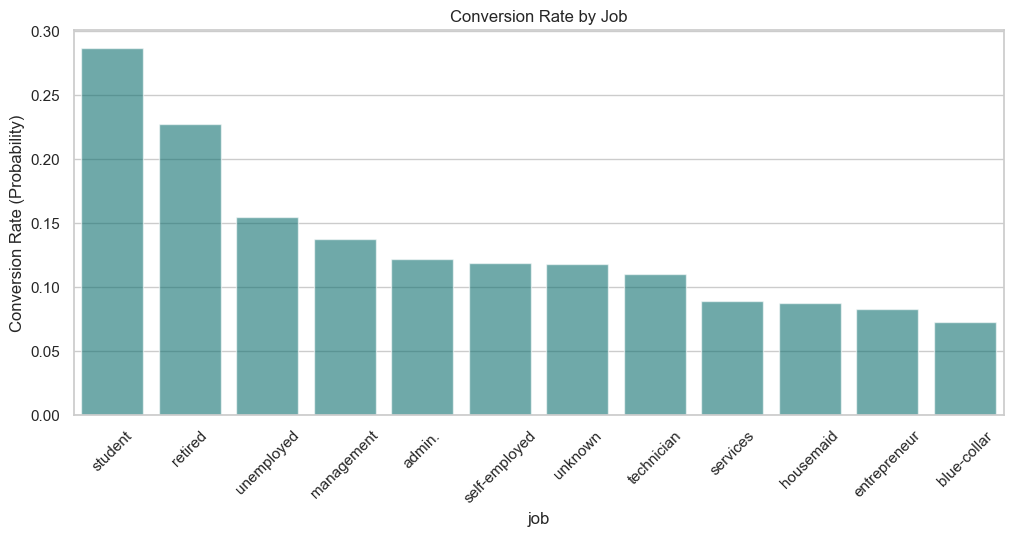

shape: (3, 3)
┌──────────┬───────┬─────────────────┐
│ marital  ┆ count ┆ conversion_rate │
│ ---      ┆ ---   ┆ ---             │
│ str      ┆ u32   ┆ f64             │
╞══════════╪═══════╪═════════════════╡
│ single   ┆ 12790 ┆ 0.149492        │
│ divorced ┆ 5207  ┆ 0.119455        │
│ married  ┆ 27214 ┆ 0.101235        │
└──────────┴───────┴─────────────────┘


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/3560971658.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


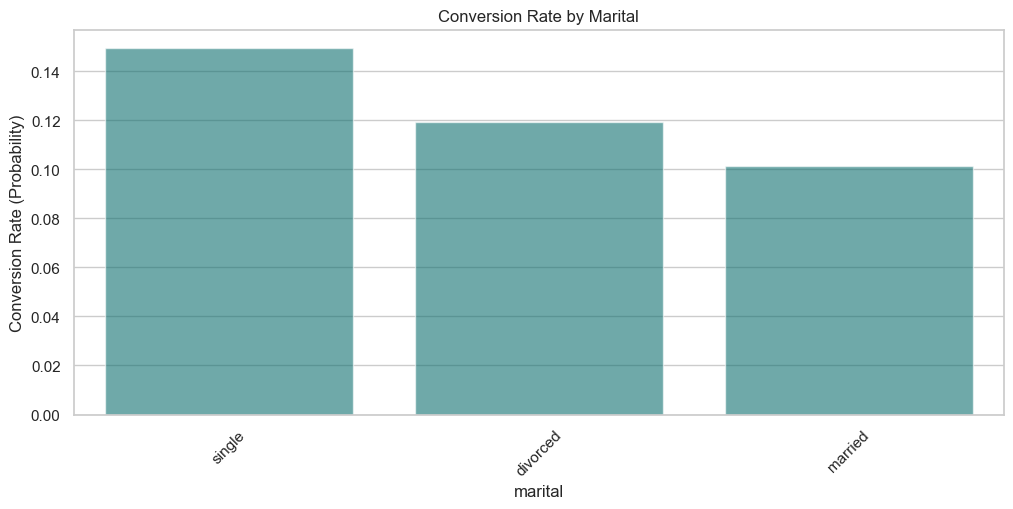

/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/3560971658.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


shape: (4, 3)
┌───────────┬───────┬─────────────────┐
│ education ┆ count ┆ conversion_rate │
│ ---       ┆ ---   ┆ ---             │
│ str       ┆ u32   ┆ f64             │
╞═══════════╪═══════╪═════════════════╡
│ tertiary  ┆ 13301 ┆ 0.150064        │
│ unknown   ┆ 1857  ┆ 0.135703        │
│ secondary ┆ 23202 ┆ 0.105594        │
│ primary   ┆ 6851  ┆ 0.086265        │
└───────────┴───────┴─────────────────┘


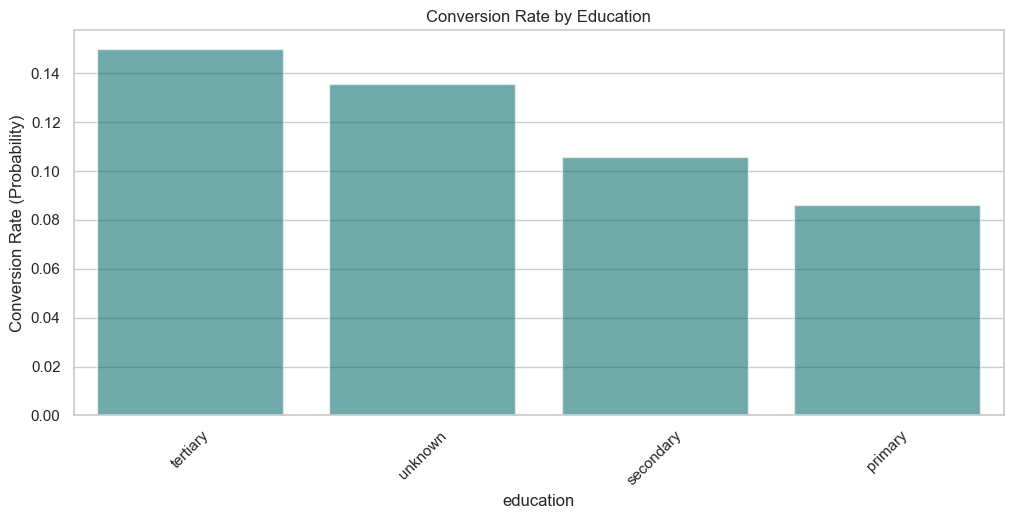

shape: (3, 3)
┌───────────┬───────┬─────────────────┐
│ contact   ┆ count ┆ conversion_rate │
│ ---       ┆ ---   ┆ ---             │
│ str       ┆ u32   ┆ f64             │
╞═══════════╪═══════╪═════════════════╡
│ cellular  ┆ 29285 ┆ 0.149189        │
│ telephone ┆ 2906  ┆ 0.134205        │
│ unknown   ┆ 13020 ┆ 0.040707        │
└───────────┴───────┴─────────────────┘


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/3560971658.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


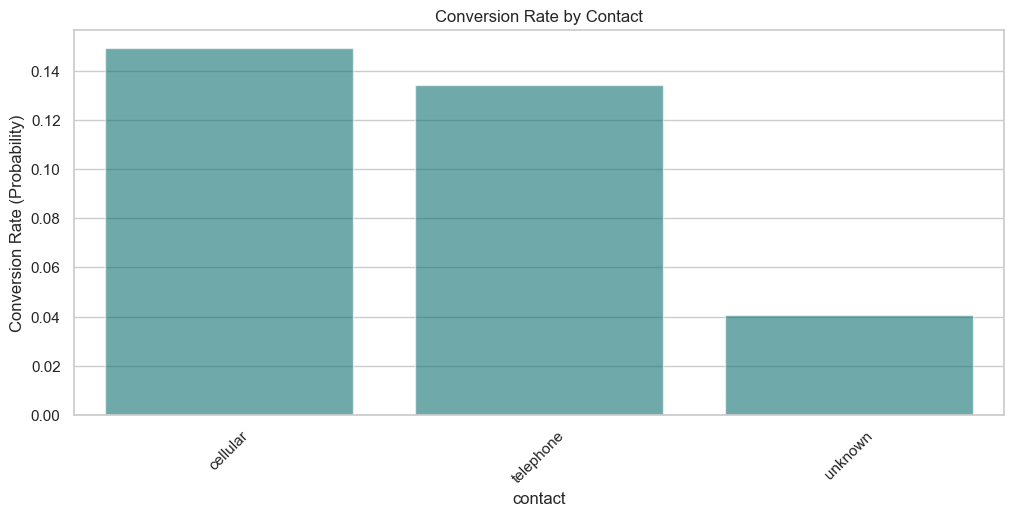

/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/3560971658.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


shape: (12, 3)
┌───────┬───────┬─────────────────┐
│ month ┆ count ┆ conversion_rate │
│ ---   ┆ ---   ┆ ---             │
│ str   ┆ u32   ┆ f64             │
╞═══════╪═══════╪═════════════════╡
│ mar   ┆ 477   ┆ 0.519916        │
│ dec   ┆ 214   ┆ 0.46729         │
│ sep   ┆ 579   ┆ 0.464594        │
│ oct   ┆ 738   ┆ 0.437669        │
│ apr   ┆ 2932  ┆ 0.196794        │
│ …     ┆ …     ┆ …               │
│ jun   ┆ 5341  ┆ 0.102228        │
│ nov   ┆ 3970  ┆ 0.101511        │
│ jan   ┆ 1403  ┆ 0.101212        │
│ jul   ┆ 6895  ┆ 0.090935        │
│ may   ┆ 13766 ┆ 0.067195        │
└───────┴───────┴─────────────────┘


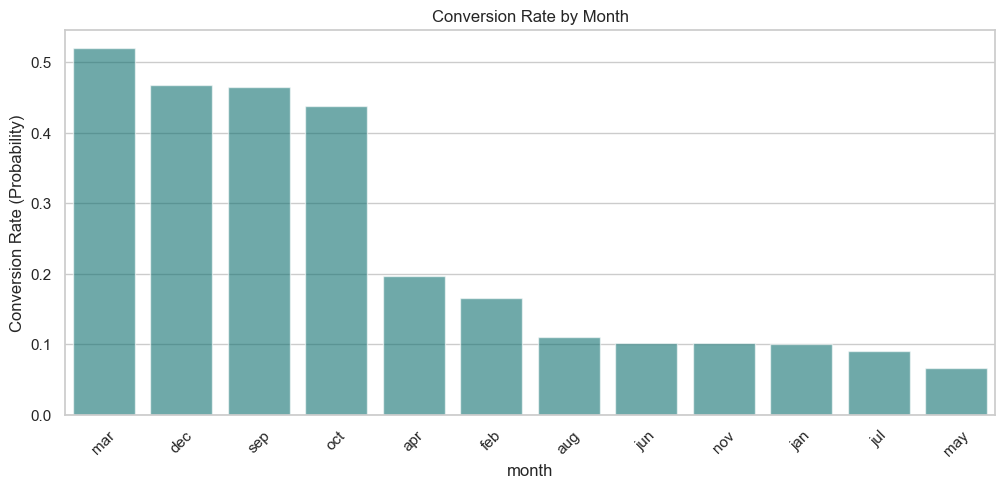

In [8]:
def plot_conversion_rate(df, col):
    # Aggregation: Group by column -> Calculate Mean of Target (Conversion Rate)
    agg = (
        df.group_by(col)
        .agg([
            pl.count().alias("count"),
            pl.col("target").mean().alias("conversion_rate")
        ])
        .sort("conversion_rate", descending=True)
    )
    
    # Plotting
    plt.figure(figsize=(12, 5))
    
    # Bar 1: The conversion rate (The signal)
    ax1 = sns.barplot(data=agg.to_pandas(), x=col, y="conversion_rate", color="teal", alpha=0.6)
    ax1.set_ylabel("Conversion Rate (Probability)")
    ax1.tick_params(axis='x', rotation=45)
    
    # Bar 2: The volume (The confidence) - plotted on secondary axis if needed, 
    # but here we keep it simple to avoid clutter. 
    # Instead, we just print the table to see small sample sizes.
    print(agg)
    plt.title(f"Conversion Rate by {col.title()}")
    plt.show()

# Loop through key categorical columns
for col in ["job", "marital", "education", "contact", "month"]:
    plot_conversion_rate(df, col)

### Correlation Matrix

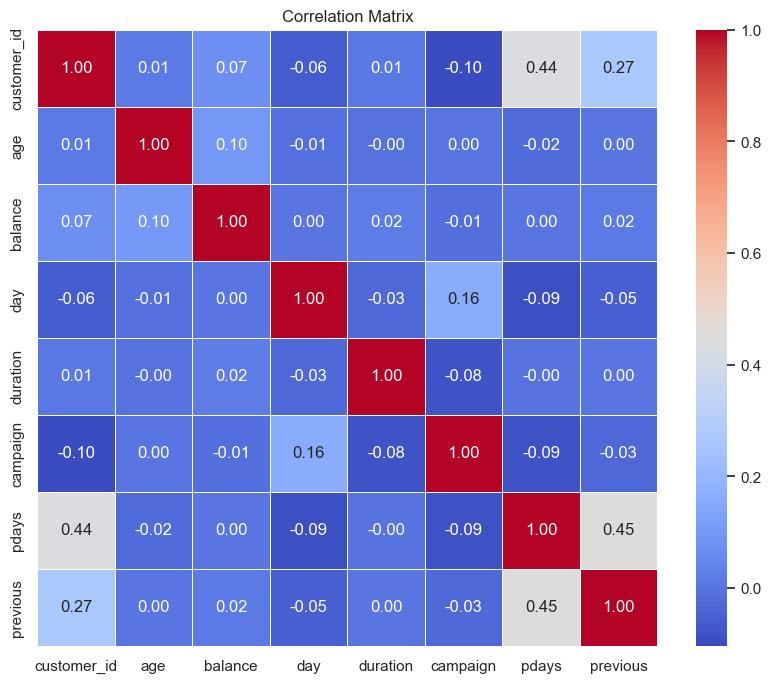

In [9]:
# Select numeric columns including our new 'target'
corr_df = df.select(pl.col(pl.Int64, pl.Float64, pl.UInt32))

# Calculate correlation matrix
# Polars .corr() returns a DataFrame, we convert to pandas for Seaborn
corr_matrix = corr_df.corr().to_pandas()

# Set the index to match columns for the heatmap labels
corr_matrix.index = corr_df.columns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


### Duration leakage check

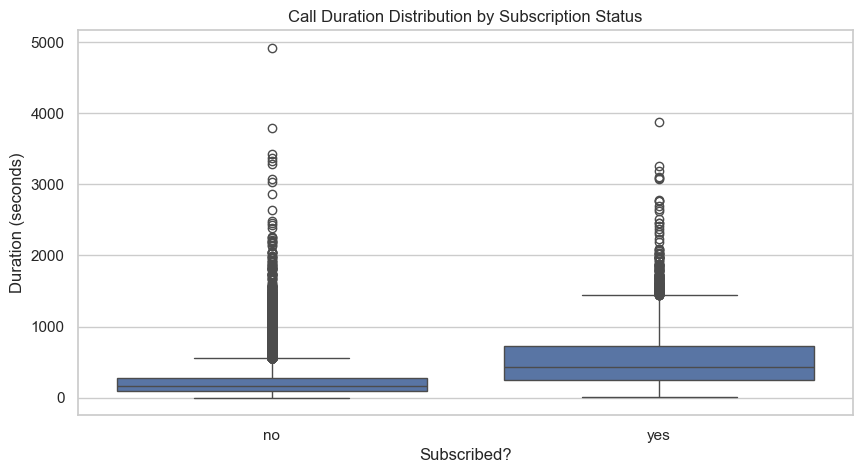

INSIGHT: Note how 'yes' responses correlate with significantly higher duration.
Since we don't know duration before making the call, this confirms it is a leakage feature.


In [10]:
# Boxplot of Duration vs Outcome
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.to_pandas(), x="y", y="duration")
plt.title("Call Duration Distribution by Subscription Status")
plt.xlabel("Subscribed?")
plt.ylabel("Duration (seconds)")
plt.show()

# Interpretation printed for the notebook
print("INSIGHT: Note how 'yes' responses correlate with significantly higher duration.")
print("Since we don't know duration before making the call, this confirms it is a leakage feature.")

### Numeric Features vs Target

/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/918304765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x="y", y=col, ax=axes[i], palette="Set2")
/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/918304765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x="y", y=col, ax=axes[i], palette="Set2")
/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/918304765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.to_pandas(), x="y", y=col, ax=ax

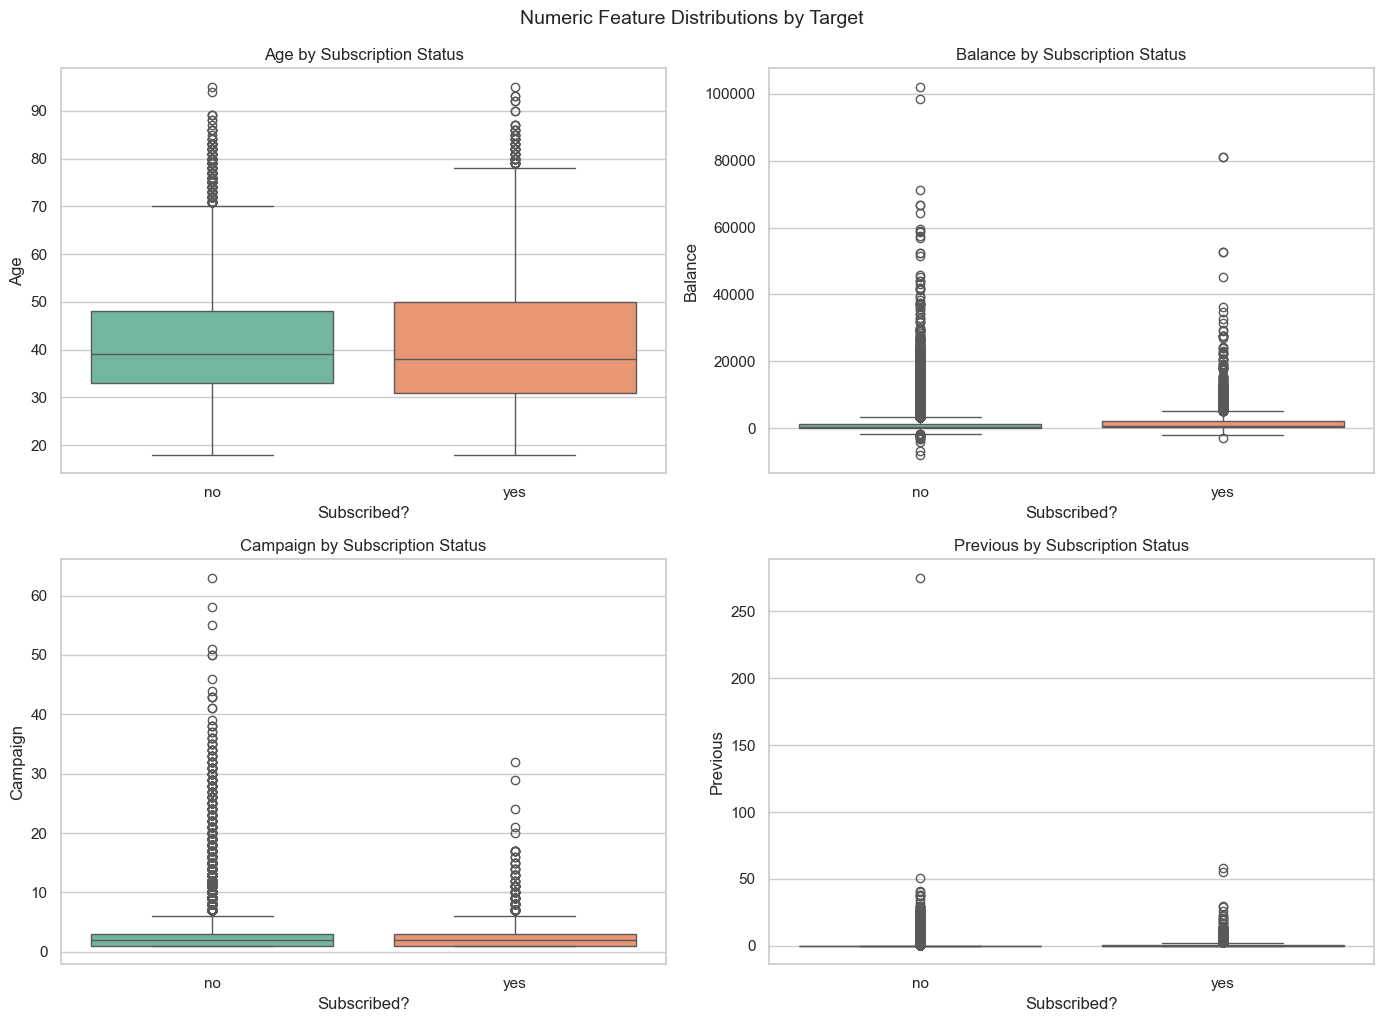

In [11]:
# Numeric feature distributions by target class
num_features = ["age", "balance", "campaign", "previous"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(data=df.to_pandas(), x="y", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col.title()} by Subscription Status")
    axes[i].set_xlabel("Subscribed?")
    axes[i].set_ylabel(col.title())

plt.tight_layout()
plt.suptitle("Numeric Feature Distributions by Target", y=1.02, fontsize=14)
plt.show()

### Age Distribution

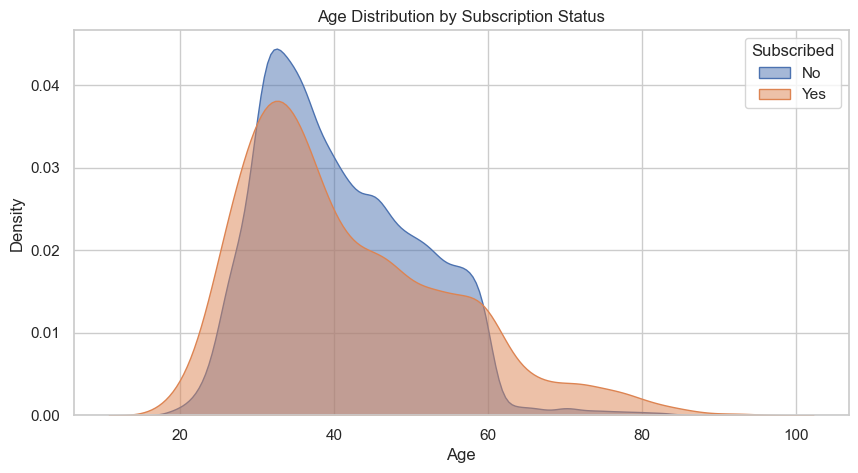

INSIGHT: Subscribers skew slightly younger (students) and older (retirees).


In [12]:
# Overlaid KDE for age by target
plt.figure(figsize=(10, 5))
df_pandas = df.to_pandas()

sns.kdeplot(data=df_pandas[df_pandas["y"] == "no"], x="age", label="No", fill=True, alpha=0.5)
sns.kdeplot(data=df_pandas[df_pandas["y"] == "yes"], x="age", label="Yes", fill=True, alpha=0.5)

plt.title("Age Distribution by Subscription Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Subscribed")
plt.show()

print("INSIGHT: Subscribers skew slightly younger (students) and older (retirees).")

### Balance Distribution by Target

Clipping balance range to: -627.0 (1%) - 13165.0 (99%)


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/1023981740.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clipped.to_pandas(), x="y", y="balance_clipped", palette="Set2")


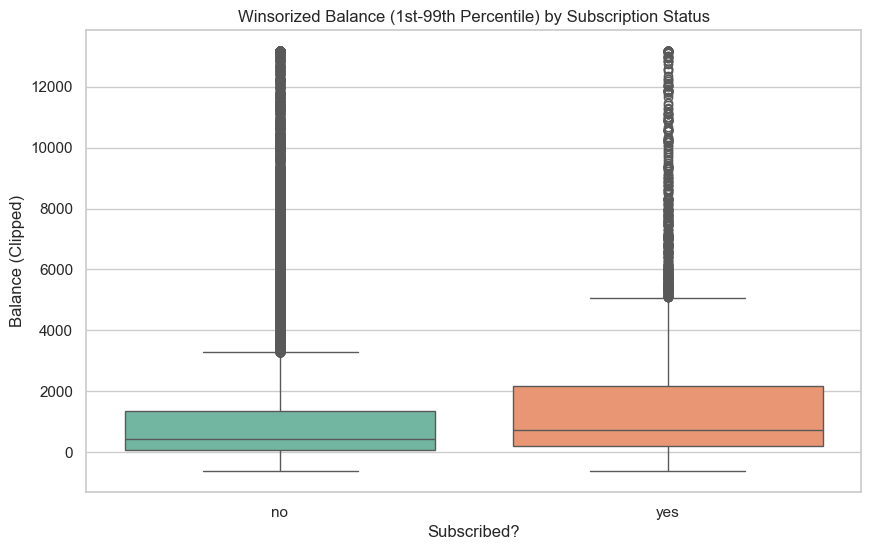

DECISION: Pipeline will apply RobustScaler or simple Clipping to 'balance' to handle outliers.


In [13]:
# --- ROBUST SCALING PREP ---
# Strategy: Winsorize (Clip) Balance to 1st and 99th percentiles.
# This removes the effect of extreme billionaires/debtors without breaking the scale.

q01 = df["balance"].quantile(0.01)
q99 = df["balance"].quantile(0.99)

print(f"Clipping balance range to: {q01} (1%) - {q99} (99%)")

# Create a temporary view to visualize the effect
df_clipped = df.with_columns(
    pl.col("balance").clip(q01, q99).alias("balance_clipped")
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clipped.to_pandas(), x="y", y="balance_clipped", palette="Set2")
plt.title("Winsorized Balance (1st-99th Percentile) by Subscription Status")
plt.xlabel("Subscribed?")
plt.ylabel("Balance (Clipped)")
plt.show()

print("DECISION: Pipeline will apply RobustScaler or simple Clipping to 'balance' to handle outliers.")

### pdays Deep Dive

pdays value distribution:
shape: (10, 2)
┌───────┬───────┐
│ pdays ┆ count │
│ ---   ┆ ---   │
│ i64   ┆ u32   │
╞═══════╪═══════╡
│ 655   ┆ 1     │
│ 587   ┆ 1     │
│ 126   ┆ 22    │
│ 871   ┆ 1     │
│ 375   ┆ 2     │
│ 391   ┆ 9     │
│ 262   ┆ 26    │
│ 648   ┆ 1     │
│ 81    ┆ 11    │
│ 474   ┆ 2     │
└───────┴───────┘

Percentage of pdays = -1: 81.74%

Conversion rate by prior contact status:
shape: (2, 3)
┌──────────────────────┬───────┬─────────────────┐
│ was_contacted_before ┆ count ┆ conversion_rate │
│ ---                  ┆ ---   ┆ ---             │
│ str                  ┆ u32   ┆ f64             │
╞══════════════════════╪═══════╪═════════════════╡
│ Yes                  ┆ 8257  ┆ 0.230713        │
│ No                   ┆ 36954 ┆ 0.091573        │
└──────────────────────┴───────┴─────────────────┘


/var/folders/_p/jgv_hz1d66n9rdd5yq1k726r0000gn/T/ipykernel_71125/1051670903.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contact_conv.to_pandas(), x="was_contacted_before", y="conversion_rate", palette="Set2")


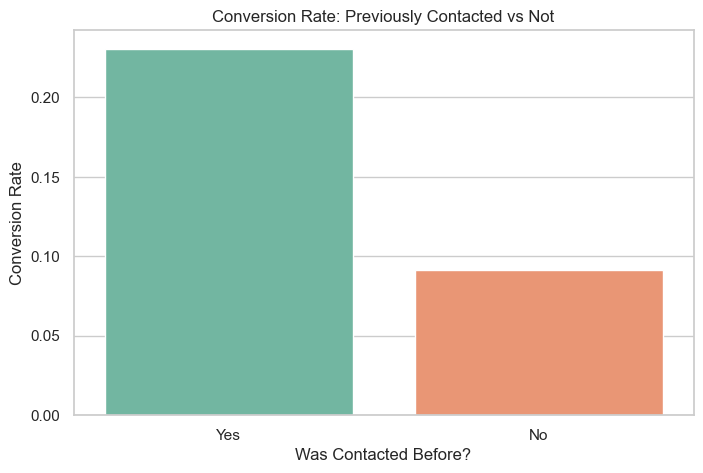


INSIGHT: Previously contacted customers convert at a much higher rate.
ACTION: Engineer 'was_contacted_before' as a binary feature instead of using raw pdays.


In [14]:
# Investigate pdays distribution and create binary feature
print("pdays value distribution:")
print(df["pdays"].value_counts().head(10))

# What percentage is -1?
pdays_minus1_pct = (df["pdays"] == -1).sum() / df.height * 100
print(f"\nPercentage of pdays = -1: {pdays_minus1_pct:.2f}%")

# Create binary feature for analysis
df = df.with_columns(
    pl.when(pl.col("pdays") == -1)
    .then(pl.lit("No"))
    .otherwise(pl.lit("Yes"))
    .alias("was_contacted_before")
)

# Conversion rate by prior contact status
contact_conv = (
    df.group_by("was_contacted_before")
    .agg([
        pl.len().alias("count"),
        pl.col("target").mean().alias("conversion_rate")
    ])
    .sort("conversion_rate", descending=True)
)
print("\nConversion rate by prior contact status:")
print(contact_conv)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=contact_conv.to_pandas(), x="was_contacted_before", y="conversion_rate", palette="Set2")
plt.title("Conversion Rate: Previously Contacted vs Not")
plt.xlabel("Was Contacted Before?")
plt.ylabel("Conversion Rate")
plt.show()

print("\nINSIGHT: Previously contacted customers convert at a much higher rate.")
print("ACTION: Engineer 'was_contacted_before' as a binary feature instead of using raw pdays.")

### poutcome and previous Relationship Check

In [15]:
# Check relationship between poutcome and previous
# If previous = 0, poutcome should logically be "unknown"
cross_tab = (
    df.group_by(["previous", "poutcome"])
    .agg(pl.len().alias("count"))
    .sort(["previous", "poutcome"])
)

# Focus on previous = 0
prev_zero = cross_tab.filter(pl.col("previous") == 0)
print("When previous = 0, poutcome distribution:")
print(prev_zero)

# And when previous > 0
prev_nonzero = (
    df.filter(pl.col("previous") > 0)
    .group_by("poutcome")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print("\nWhen previous > 0, poutcome distribution:")
print(prev_nonzero)

print("\nINSIGHT: 'unknown' poutcome is always when previous=0 (no prior campaign).")
print("ACTION: Treat 'unknown' as a valid category, not as missing data.")

When previous = 0, poutcome distribution:
shape: (1, 3)
┌──────────┬──────────┬───────┐
│ previous ┆ poutcome ┆ count │
│ ---      ┆ ---      ┆ ---   │
│ i64      ┆ str      ┆ u32   │
╞══════════╪══════════╪═══════╡
│ 0        ┆ unknown  ┆ 36954 │
└──────────┴──────────┴───────┘

When previous > 0, poutcome distribution:
shape: (4, 2)
┌──────────┬───────┐
│ poutcome ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ failure  ┆ 4901  │
│ other    ┆ 1840  │
│ success  ┆ 1511  │
│ unknown  ┆ 5     │
└──────────┴───────┘

INSIGHT: 'unknown' poutcome is always when previous=0 (no prior campaign).
ACTION: Treat 'unknown' as a valid category, not as missing data.


In [16]:
# --- FEATURE SELECTION ---
# ACTION: Drop 'duration' (Leakage), 'pdays' (Redundant with poutcome) and 'y' (target created)

features_to_drop = ["duration", "pdays", "y"]

# Check if they exist before dropping to avoid errors if run twice
existing_drop_cols = [c for c in features_to_drop if c in df.columns]

if existing_drop_cols:
    df_final = df.drop(existing_drop_cols)
    print(f"Dropped columns: {existing_drop_cols}")
else:
    df_final = df
    print("Columns already dropped.")

# Verify final columns
print(f"Final Feature Set ({len(df_final.columns)} columns):")
print(df_final.columns)

Dropped columns: ['duration', 'pdays', 'y']
Final Feature Set (18 columns):
['customer_id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'previous', 'poutcome', 'profile_id', 'target', 'was_contacted_before']


### Categorical Feature Multicollinearity

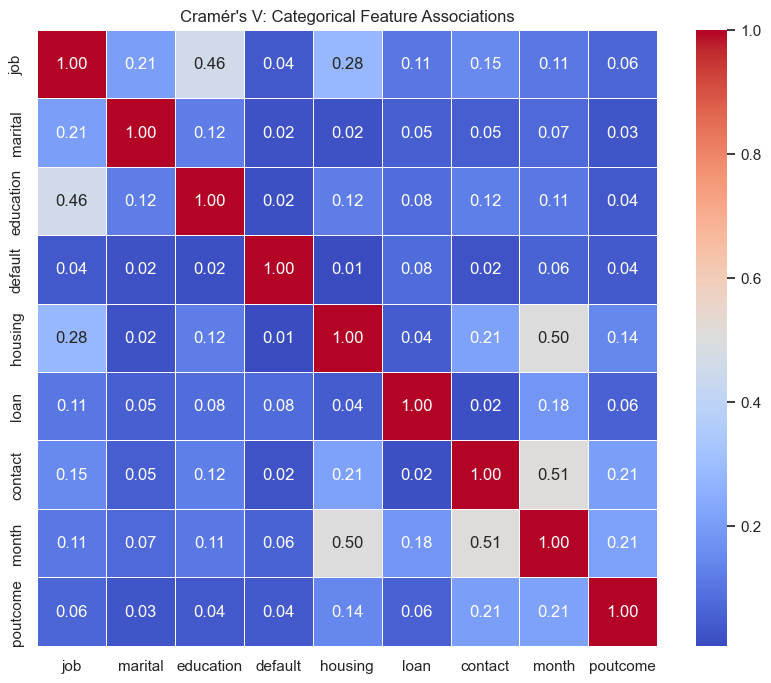

INSIGHT: Values > 0.3 indicate moderate association; > 0.5 is strong.
ACTION: Check for redundant categorical features that may cause multicollinearity.


In [17]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    # Convert polars Series to pandas for crosstab
    if isinstance(x, pl.Series):
        x = x.to_pandas()
    if isinstance(y, pl.Series):
        y = y.to_pandas()
    
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Categorical columns to check
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

# Assuming df is a Polars DataFrame
# If you need to read from CSV: df = pl.read_csv("your_file.csv")

# Compute Cramér's V matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            # Access Polars DataFrame columns directly
            cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Cramér's V: Categorical Feature Associations")
plt.show()

print("INSIGHT: Values > 0.3 indicate moderate association; > 0.5 is strong.")
print("ACTION: Check for redundant categorical features that may cause multicollinearity.")

### Unknown Value Handling Strategy

In [18]:
# Document unknown value handling strategy
unknown_strategy = {
    "job": {
        "unknown_count": (df["job"] == "unknown").sum(),
        "percentage": (df["job"] == "unknown").sum() / df_final.height * 100,
        "strategy": "Treat as separate category - only 0.6% of data"
    },
    "education": {
        "unknown_count": (df["education"] == "unknown").sum(),
        "percentage": (df["education"] == "unknown").sum() / df_final.height * 100,
        "strategy": "Treat as separate category - 4.1% of data, has distinct conversion rate"
    },
    "contact": {
        "unknown_count": (df["contact"] == "unknown").sum(),
        "percentage": (df["contact"] == "unknown").sum() / df_final.height * 100,
        "strategy": "Treat as separate category - 28.8% of data, very informative (low conversion)"
    },
    "poutcome": {
        "unknown_count": (df["poutcome"] == "unknown").sum(),
        "percentage": (df["poutcome"] == "unknown").sum() / df_final.height * 100,
        "strategy": "Treat as separate category - represents 'no prior campaign' (correlates with previous=0)"
    }
}

print("=" * 60)
print("UNKNOWN VALUE HANDLING STRATEGY")
print("=" * 60)
for col, info in unknown_strategy.items():
    print(f"\n{col}:")
    print(f"  Count: {info['unknown_count']} ({info['percentage']:.2f}%)")
    print(f"  Strategy: {info['strategy']}")

print("\n" + "=" * 60)
print("DECISION: All 'unknown' values will be treated as valid categories,")
print("not as missing data requiring imputation.")
print("=" * 60)

UNKNOWN VALUE HANDLING STRATEGY

job:
  Count: 288 (0.64%)
  Strategy: Treat as separate category - only 0.6% of data

education:
  Count: 1857 (4.11%)
  Strategy: Treat as separate category - 4.1% of data, has distinct conversion rate

contact:
  Count: 13020 (28.80%)
  Strategy: Treat as separate category - 28.8% of data, very informative (low conversion)

poutcome:
  Count: 36959 (81.75%)
  Strategy: Treat as separate category - represents 'no prior campaign' (correlates with previous=0)

DECISION: All 'unknown' values will be treated as valid categories,
not as missing data requiring imputation.


### Input schema generation

In [19]:
import json

# Save Data to Parquet
# I prefer Parquet here because:
#   a) It keeps the original data types intact.
#   b) It's column-oriented and compressed, so training is faster.
#   c) It avoids CSV parsing inconsistencies between steps.
output_file = "dataset_prepared.parquet"
df_final.write_parquet(output_file)
print(f"Saved cleaned dataset to {output_file} ({df_final.shape})")

# Save Feature Contract (Schema)
# This JSON becomes the single source of truth for the serving API.
# It ensures the API only receives values the model was actually trained on.
schema_contract = {
    "numeric_features": [
        c for c in df_final.columns 
        if df_final[c].dtype in [pl.Float64, pl.Int64] 
        and c not in ["target", "customer_id", "profile_id"]
    ],
    "categorical_features": [
        c for c in df_final.columns 
        if df_final[c].dtype == pl.Utf8 
        and c not in ["customer_id", "profile_id"]
    ],
    "target": "target",
    "id_col": "customer_id",
    "group_col": "profile_id",
    # I list valid categories so the API can validate inputs later.
    "valid_categories": {
        col: sorted(df_final[col].unique().to_list())
        for col in df_final.columns 
        if df_final[col].dtype == pl.Utf8
    }
}

with open("schema_contract.json", "w") as f:
    json.dump(schema_contract, f, indent=2)

print("Saved schema contract to schema_contract.json")


Saved cleaned dataset to dataset_prepared.parquet ((45211, 18))
Saved schema contract to schema_contract.json


## Export Checklist for Training Pipeline

When building the `train.py` script, ensure the following artefacts are saved (pickled) after training. The API cannot run without them.

1.  **`model.pkl`**: The trained classifier (e.g., XGBoost, RandomForest).
2.  **`preprocessor.pkl`**: The Scikit-Learn `ColumnTransformer` containing:
    * The fitted `OneHotEncoder` (with `handle_unknown='ignore'`).
    * The fitted `RobustScaler` (for the balance column).
3.  **`features_names.json`**: An ordered list of the columns expected by the model *after* preprocessing (useful for debugging feature importance).
4.  **`schema_config.json`**: The dictionary of valid categories generated in the cell above (used to validate incoming JSON requests before they hit the model).